In [116]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [117]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export_torch.xlsx')

In [118]:
raw_data_codes=[]

for i in range(0,raw_data.shape[0]):
    raw_data_codes.append(raw_data.iloc[i,2][6:8])

raw_data['Codes']=raw_data_codes

torch_codes_02=raw_data[raw_data['Codes'].str.contains('02')]
torch_codes_04=raw_data[raw_data['Codes'].str.contains('04')]
torch_codes_0204=pd.concat([torch_codes_02,torch_codes_04])

torch_codes_0204.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\torch_analysis.csv',sep=',')

ignition_on_interval=[]
ignition_off_interval=[]
io=[]
odometer=[]
date=[]
ext_ps=[]
speed=[]
#over_speed=[]
gnss=[]
#a_code=[]
#direction=[]
accum_fuel_consumption=[]
#instant_fuel_consumption=[]
rpm=[]
cool_temp=[]
#air_in_flow_temp=[]
engine_load=[]
remain_fuel_rate=[]

for i in range(0,torch_codes_0204.shape[0]):
    ignition_on_interval.append(int(torch_codes_0204.iloc[i,2][32:36],16))
    ignition_off_interval.append(int(torch_codes_0204.iloc[i,2][36:40],16))
    io.append(bin(int(torch_codes_0204.iloc[i,2][64:68],16)))
    odometer.append(int(torch_codes_0204.iloc[i,2][72:80],16))
    date.append(torch_codes_0204.iloc[i,2][82:94])
    ext_ps.append((float(int(torch_codes_0204.iloc[i,2][126:130])))/100)
    speed.append(int(torch_codes_0204.iloc[i,2][131:133],16))    
    #over_speed.append(torch_codes_0204.iloc[i,2])
    gnss.append(int(torch_codes_0204.iloc[i,2][51:52],16))
    #a_code.append(torch_codes_0204.iloc[])
    #direction.append(torch_codes_0204.iloc[i,2])
    accum_fuel_consumption.append(float(int(torch_codes_0204.iloc[i,2][134:142],16))/1000)
    #instant_fuel_consumption.append(torch_codes_0204.iloc[i,2]) invalid!
    rpm.append(int(torch_codes_0204.iloc[i,2][150:154],16))
    cool_temp.append(int(torch_codes_0204.iloc[i,2][158:160],16))
    #air_in_flow_temp.append(torch_codes_0204.iloc[i,2])
    engine_load.append(int(torch_codes_0204.iloc[i,2][162:164],16))
    remain_fuel_rate.append(torch_codes_0204.iloc[i,2][166:168])

torch_codes_0204['i_on']=ignition_on_interval
torch_codes_0204['i_off']=ignition_off_interval
torch_codes_0204['io']=io
torch_codes_0204['odometer']=odometer
torch_codes_0204['date']=date
torch_codes_0204['ext_ps']=ext_ps
torch_codes_0204['speed']=speed
torch_codes_0204['gnss']=gnss
torch_codes_0204['acc_fuel_c']=accum_fuel_consumption
torch_codes_0204['rpm']=rpm
torch_codes_0204['cool_temp']=cool_temp
torch_codes_0204['remain_fuel']=remain_fuel_rate
torch_codes_0204['engine_load']=engine_load

torch_codes_0204_ordered=torch_codes_0204.sort_values('date',ascending=True)

df=torch_codes_0204_ordered[['i_on','i_off','io','odometer','date','ext_ps','speed','acc_fuel_c','rpm','remain_fuel','gnss','cool_temp','Status','engine_load']]

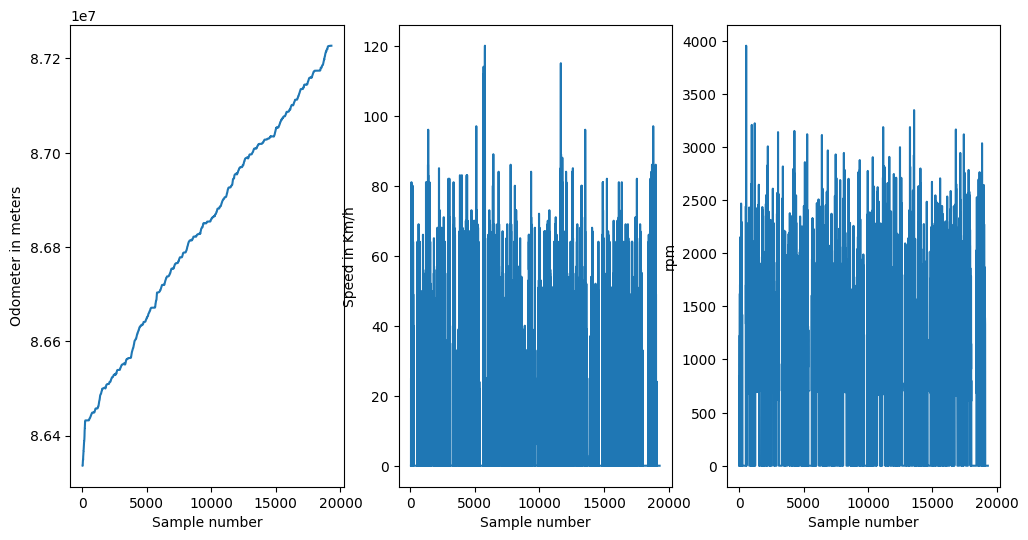

In [119]:
odometer_data=[]
rpm_data=[]
speed_data=[]
fuel_data=[]
x_axis_odo_speed=[]
x_axis_rpm=[]
date=[]
status=[]

for i in range(0,df.shape[0]):
    if int(df.iloc[i,3]>80000000):
        status.append(df.iloc[i,12])
        odometer_data.append(int(df.iloc[i,3]))
        #rpm_data.append(int(df.iloc[i,8]))
        speed_data.append(int(df.iloc[i,6]))
        #fuel_data.append((int(df.iloc[i,9],16) & 127))
        date.append(df.iloc[i,4])
        x_axis_odo_speed.append(i)

for i in range(0,df.shape[0]):
        if df.iloc[i,8]<65535:
                status.append(df.iloc[i,12])
                rpm_data.append(df.iloc[i,8])
                date.append(df.iloc[i,4])
                x_axis_rpm.append(i) 

fig, ax = plt.subplots(1,3, figsize=(12, 6))

ax[0].set_xlabel('Sample number')
ax[0].set_ylabel('Odometer in meters')
ax[1].set_xlabel('Sample number')
ax[1].set_ylabel('Speed in Km/h')
ax[2].set_xlabel('Sample number')
ax[2].set_ylabel('rpm')
ax[0].plot(x_axis_odo_speed,odometer_data)
ax[1].plot(x_axis_odo_speed,speed_data)
ax[2].plot(x_axis_rpm,rpm_data)


Fuel

Text(0.5, 0, 'sample number')

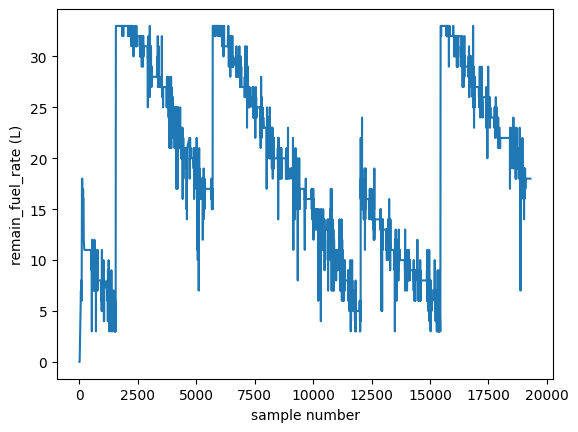

In [120]:
fuel_data=[]
x_axis_fuel=[]
date=[]
status=[]
status_aux=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if df.iloc[i,9]!='FF':               
        aux_data=df.iloc[i,12]
        if (len(aux_data)<170):
            status.append(df.iloc[i,12])
            x_axis_fuel.append(i) 
            fuel_data.append((int(df.iloc[i,9],16) & 127))
            date.append(df.iloc[i,4])

plt.plot(x_axis_fuel,fuel_data)
plt.ylabel("remain_fuel_rate (L)")
plt.xlabel('sample number')

Cooling fluid Temperature & Engine Load

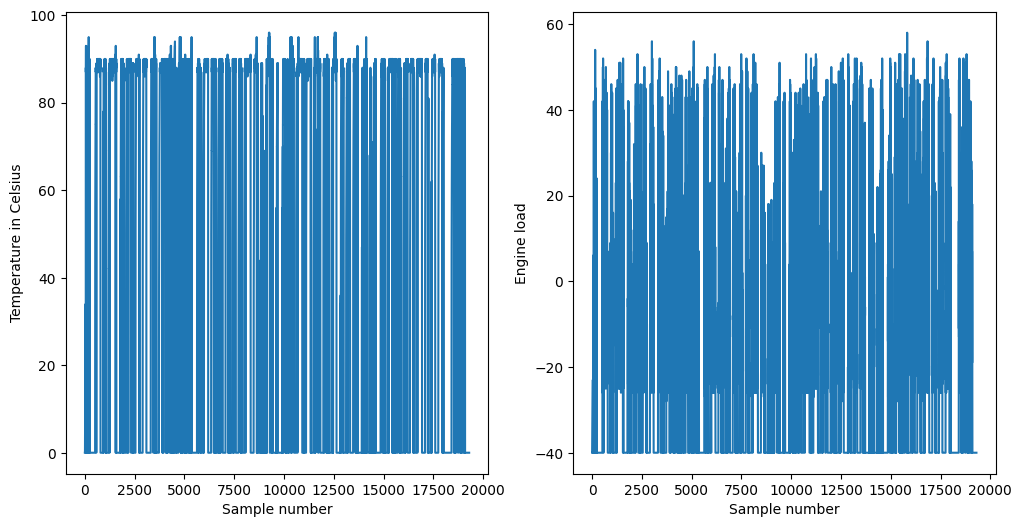

In [121]:
temp_data=[]
engine_data=[]
x_axis_temp=[]
date=[]
status=[]
x_axis_engine=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if df.iloc[i,11]!=255:               
        aux_data=df.iloc[i,11]
        status.append(df.iloc[i,12])
        temp_data.append(df.iloc[i,11]-40)
        x_axis_temp.append(i)         
        date.append(df.iloc[i,4])

for i in range(0,df.shape[0]):
    if df.iloc[i,13]!=255:               
        aux_data=df.iloc[i,13]
        status.append(df.iloc[i,12])
        engine_data.append(df.iloc[i,13]-40)
        x_axis_engine.append(i)         
        date.append(df.iloc[i,4])

fig, ax = plt.subplots(1,2, figsize=(12, 6))

ax[0].set_xlabel('Sample number')
ax[0].set_ylabel('Temperature in Celsius')
ax[1].set_xlabel('Sample number')
ax[1].set_ylabel('Engine load')
ax[0].plot(x_axis_temp,temp_data)
ax[1].plot(x_axis_engine,engine_data)
